# People on Banknotes

Whose faces appear on banknotes?

The file `people-on-banknotes.csv` contains data about individuals featured on banknotes from 38 countries. This dataset spans all 22 subregions and sub-subregions of the world, as defined by the United Nations Statistics Division's geoscheme.

It profiles 241 people, detailing their occupations and the year they first appeared on a banknote. Additionally, it includes their year of death — or `NaN` if they were still alive when the dataset was compiled.

Most banknotes were issued after the featured individual’s death. The column `first_death_diff` calculates the difference between the year of their first appearance on a banknote and their year of death (or remains `NaN` if the person was still living at the time of curation).




In [2]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'people-on-banknotes.csv'.

# from google.colab import files
# uploaded = files.upload()

In [3]:
import pandas as pd

df = pd.read_csv('people-on-banknotes.csv')
df

,country,currency,name,gender,occupation,value,first_appearance,death,first_death_diff,currency_code
0,Argentina,Argentine Peso,Eva Perón,F,Activist,100,2012,1952,60.0,ARS
1,Argentina,Argentine Peso,Julio Argentino Roca,M,Head of Gov't,100,1988,1914,74.0,ARS
2,Argentina,Argentine Peso,Domingo Faustino Sarmiento,M,Head of Gov't,50,1999,1888,111.0,ARS
3,Argentina,Argentine Peso,Juan Manuel de Rosas,M,Politician,20,1992,1877,115.0,ARS
4,Argentina,Argentine Peso,Manuel Belgrano,M,Founder,10,1970,1820,150.0,ARS
...,...,...,...,...,...,...,...,...,...,...
274,Venezuela,Venezuelan Bolivar,Francisco de Miranda,M,Military,200,1968,1816,152.0,VES
275,Venezuela,Venezuelan Bolivar,Simón Rodrigues,M,Educator,20,2007,1854,153.0,VES
276,Venezuela,Venezuelan Bolivar,Ezequiel Zamora,M,Military,100,2018,1860,158.0,VES
277,Venezuela,Venezuelan Bolivar,Rafael Urdaneta,M,Head of Gov't,10,2018,1845,173.0,VES


### Quick cleaning

The same person can appear on multiple banknotes. Below we drop the `value` column and remove duplicate people.

In [4]:
df = df.drop(columns=['value'])
df = df.drop_duplicates(subset="name")
df

,country,currency,name,gender,occupation,first_appearance,death,first_death_diff,currency_code
0,Argentina,Argentine Peso,Eva Perón,F,Activist,2012,1952,60.0,ARS
1,Argentina,Argentine Peso,Julio Argentino Roca,M,Head of Gov't,1988,1914,74.0,ARS
2,Argentina,Argentine Peso,Domingo Faustino Sarmiento,M,Head of Gov't,1999,1888,111.0,ARS
3,Argentina,Argentine Peso,Juan Manuel de Rosas,M,Politician,1992,1877,115.0,ARS
4,Argentina,Argentine Peso,Manuel Belgrano,M,Founder,1970,1820,150.0,ARS
...,...,...,...,...,...,...,...,...,...
274,Venezuela,Venezuelan Bolivar,Francisco de Miranda,M,Military,1968,1816,152.0,VES
275,Venezuela,Venezuelan Bolivar,Simón Rodrigues,M,Educator,2007,1854,153.0,VES
276,Venezuela,Venezuelan Bolivar,Ezequiel Zamora,M,Military,2018,1860,158.0,VES
277,Venezuela,Venezuelan Bolivar,Rafael Urdaneta,M,Head of Gov't,2018,1845,173.0,VES


### Project Ideas

- What proportion of individuals featured are male versus female?
	- Hint: Use `value_counts(normalize=True)` to calculate percentages.

- Are writers or politicians more commonly depicted?

- What percentage of featured individuals are musicians?

- What percentage of banknotes were issued before the person’s death?
	- Hint: Look for negative values or NaN in `first_death_diff`.

- Who is the oldest historical figure in the dataset?

- Which countries feature the oldest historical figures on their banknotes?
	- Hint: Group by country and aggregate the year of death using the median. Sort the results.

- What percentage of individuals died at least 100 years before appearing on a banknote?

- Which individuals appeared on a banknote just one year after their death?


In [5]:
# YOUR CODE HERE (add additional cells as needed)

In [7]:
df["gender"].value_counts(
    normalize=True
) * 100

gender
M    78.008299
F    21.991701
Name: proportion, dtype: float64

In [8]:
gender_percent = (
    df["gender"]
    .value_counts(normalize=True)
    * 100
)

print(gender_percent)

gender
M    78.008299
F    21.991701
Name: proportion, dtype: float64


<Axes: >

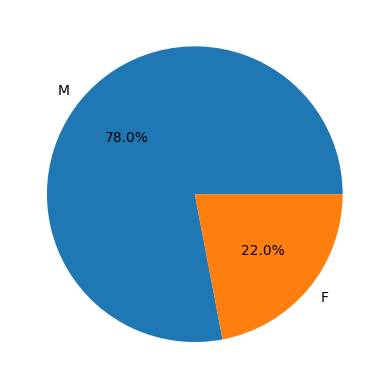

In [9]:
gender_percent.plot.pie(
    autopct="%1.1f%%"
)

In [10]:
df["occupation"].value_counts()

occupation
Writer              45
Head of Gov't       38
Politician          27
Founder             25
Revolutionary       21
STEM                16
Military            13
Visual Artist       13
Musician            12
Monarch             12
Other                5
Activist             4
Educator             4
Religious figure     3
Performer            3
Name: count, dtype: int64

In [11]:
writers = df[
    df["occupation"] == "Writer"
].shape[0]

politicians = df[
    df["occupation"] == "Politician"
].shape[0]

print("Writers:", writers)
print("Politicians:", politicians)

Writers: 45
Politicians: 27


In [12]:
#another way to do it
writers = df[
    df["occupation"]
    .str.contains(
        "Writer|Author",
        case=False,
        na=False
    )
].shape[0]

In [13]:
musicians = df[
    df["occupation"]
    .str.contains(
        "Musician",
        case=False,
        na=False
    )
]

musician_percent = (
    len(musicians) /
    len(df)
) * 100

print(musician_percent)

4.979253112033195


In [14]:
before_death = df[
    df["first_death_diff"] < 0
]

In [15]:
before_death = df[
    (df["first_death_diff"] < 0) |
    (df["first_death_diff"].isna())
]

In [16]:
percent_before = (
    len(before_death) /
    len(df)
) * 100

print(percent_before)

4.564315352697095


In [17]:
oldest = df.loc[
    df["death"].idxmin()
]

print(oldest)

country                    Tunisia
currency            Tunisian Dinar
name                      Hannibal
gender                           M
occupation                Military
first_appearance              2013
death                         -183
first_death_diff            2196.0
currency_code                  TND
Name: 234, dtype: object


In [18]:
print(
    oldest[
        ["name", "death", "country"]
    ]
)

name       Hannibal
death          -183
country     Tunisia
Name: 234, dtype: object


In [21]:
df['death'] = pd.to_numeric(df['death'])

country_age = df.groupby(
    "country"
)["death"].median()

In [22]:
country_age = country_age.sort_values()

print(country_age)

country
South Korea              1560.5
São Tomé and Príncipe    1779.5
Ukraine                  1817.5
United States            1826.0
Bolivia                  1839.5
Iceland                  1845.0
Venezuela                1849.5
Czech Republic           1869.0
Chile                    1879.0
Argentina                1888.0
Mexico                   1892.5
Japan                    1901.0
England                  1902.5
Dominican Republic       1905.0
Georgia                  1915.0
Serbia                   1927.0
Uruguay                  1931.0
Turkey                   1936.0
Australia                1936.5
Kyrgyzstan               1942.0
New Zealand              1943.5
Canada                   1943.5
Tunisia                  1943.5
Peru                     1945.0
Costa Rica               1947.0
Indonesia                1947.5
Philippines              1948.0
Colombia                 1948.0
Israel                   1956.5
Malawi                   1966.5
Jamaica                  1967.0


In [25]:
hundred_years = df[
    df["first_death_diff"] >= 100]

In [27]:
percent_100 = (
    len(hundred_years) /
    len(df)
) * 100

print(percent_100)

33.19502074688796


In [28]:
one_year = df[
    df["first_death_diff"] == 1
]

print(
    one_year[
        ["name", "country"]
    ]
)

                         name      country
63     Gabriel García Márquez     Colombia
173  General Murtala Mohammed      Nigeria
190         Corazon C. Aquino  Philippines
191           Manuel A. Roxas  Philippines


<Axes: xlabel='occupation'>

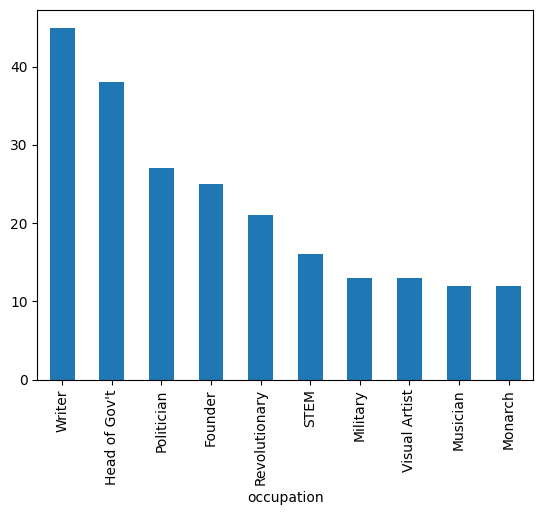

In [29]:
df["occupation"].value_counts().head(10).plot.bar()

<Axes: >

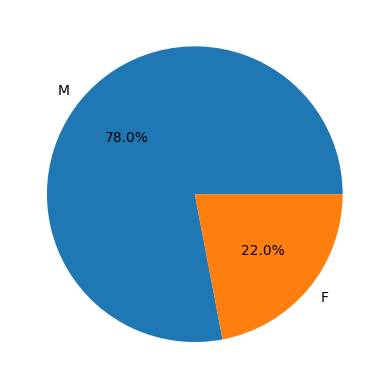

In [30]:
df["gender"].value_counts().plot.pie(
    autopct="%1.1f%%"
)

<Axes: ylabel='Frequency'>

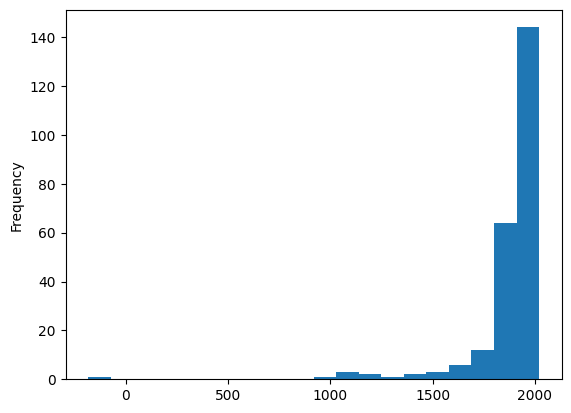

In [31]:
df["death"].plot.hist(
    bins=20
)

<Axes: ylabel='country'>

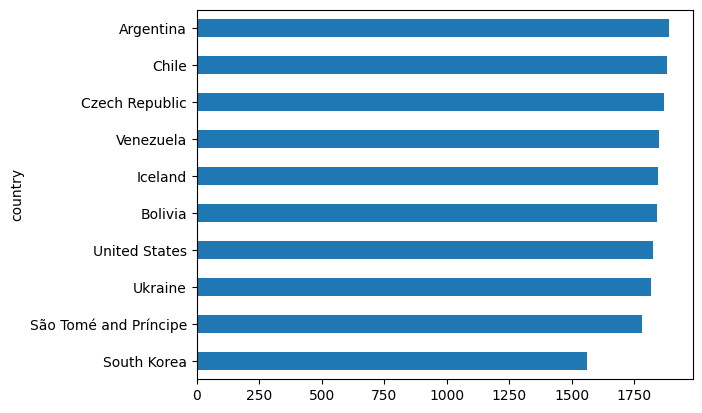

In [32]:
country_age.head(10).plot.barh(
    x="country",
    y="death"
)

In [33]:
top_jobs = df["occupation"].value_counts()

print(top_jobs)

occupation
Writer              45
Head of Gov't       38
Politician          27
Founder             25
Revolutionary       21
STEM                16
Military            13
Visual Artist       13
Musician            12
Monarch             12
Other                5
Activist             4
Educator             4
Religious figure     3
Performer            3
Name: count, dtype: int64


<Axes: ylabel='Frequency'>

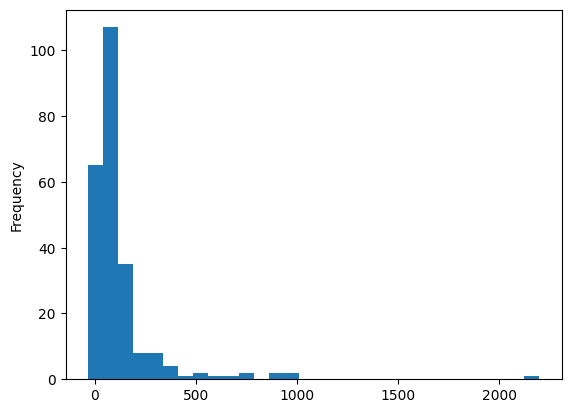

In [34]:
df["first_death_diff"].plot.hist(
    bins=30
)

In [35]:
pd.crosstab(
    df["country"],
    df["gender"]
)

gender,F,M
country,,
Argentina,1,4
Australia,5,4
Bangladesh,0,1
Bolivia,3,12
Canada,2,6
Cape Verde,1,4
Chile,1,4
China,0,1
Colombia,3,8


In [36]:
df.groupby("country")[
    "occupation"
].nunique()

country
Argentina                4
Australia                8
Bangladesh               1
Bolivia                  4
Canada                   4
Cape Verde               3
Chile                    4
China                    1
Colombia                 7
Costa Rica               3
Czech Republic           6
Dominican Republic       6
England                  4
Georgia                  7
Iceland                  3
Indonesia                5
Israel                   1
Jamaica                  3
Japan                    2
Kyrgyzstan               3
Malawi                   4
Mexico                   7
New Zealand              4
Nigeria                  5
Papua New Guinea         1
Peru                     6
Philippines              4
Serbia                   6
South Africa             1
South Korea              3
Sweden                   5
São Tomé and Príncipe    2
Tunisia                  4
Turkey                   5
Ukraine                  5
United States            2
Uruguay             

In [37]:
df["name"].value_counts()

name
Eva Perón                     1
Julio Argentino Roca          1
Domingo Faustino Sarmiento    1
Juan Manuel de Rosas          1
Manuel Belgrano               1
                             ..
Francisco de Miranda          1
Simón Rodrigues               1
Ezequiel Zamora               1
Rafael Urdaneta               1
José Félix Ribas              1
Name: count, Length: 241, dtype: int64